# KDD 2009 challenge

The cells below download the data straight from the [KDD Cup 2009 archive](https://www.kdd.org/kdd-cup/view/kdd-cup-2009/Data) and load it directly into memory.

In [1]:
import io
import urllib.request
import warnings
import zipfile

import matplotlib.pyplot as plt
import pandas as pd

from feature_engine.encoding import OneHotEncoder, RareLabelEncoder
from feature_engine.imputation import MeanMedianImputer, CategoricalImputer
from feature_engine.selection import DropConstantFeatures

# I'm updating feature-engine as we speak, but at the time
# of creating this notebook it was raising some deprecation warnings
# so I silence them here.
warnings.filterwarnings("ignore")

In [2]:
DATA_URL = "https://kdd.org/cupfiles/KDDCupData/2009/orange_small_train.data.zip"
LABELS_URL = "https://kdd.org/cupfiles/KDDCupData/2009/orange_small_train_appetency.labels"

# download and read into memory
with zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(DATA_URL).read())) as z:
    with z.open("orange_small_train.data") as f:
        data = pd.read_table(f)

target = pd.read_table(urllib.request.urlopen(LABELS_URL), header=None).loc[:, 0]

In [3]:
# drop variables where most of the rows contain NAN
data.dropna(thresh=int(0.2*len(data)), axis=1, inplace=True)

data.shape

(50000, 76)

[]

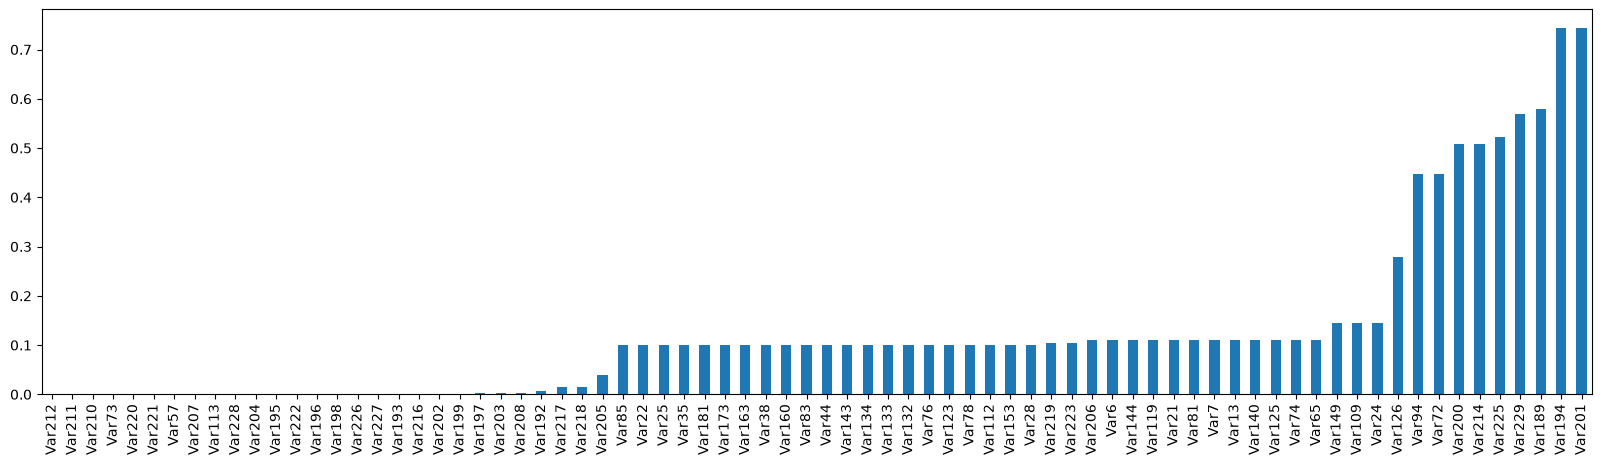

In [4]:
data.isnull().mean().sort_values().plot.bar(figsize=(20,5))

plt.plot()

In [5]:
data = MeanMedianImputer().fit_transform(data)
data = CategoricalImputer().fit_transform(data)

In [6]:
data = RareLabelEncoder(tol=0.05, n_categories=5).fit_transform(data)

[]

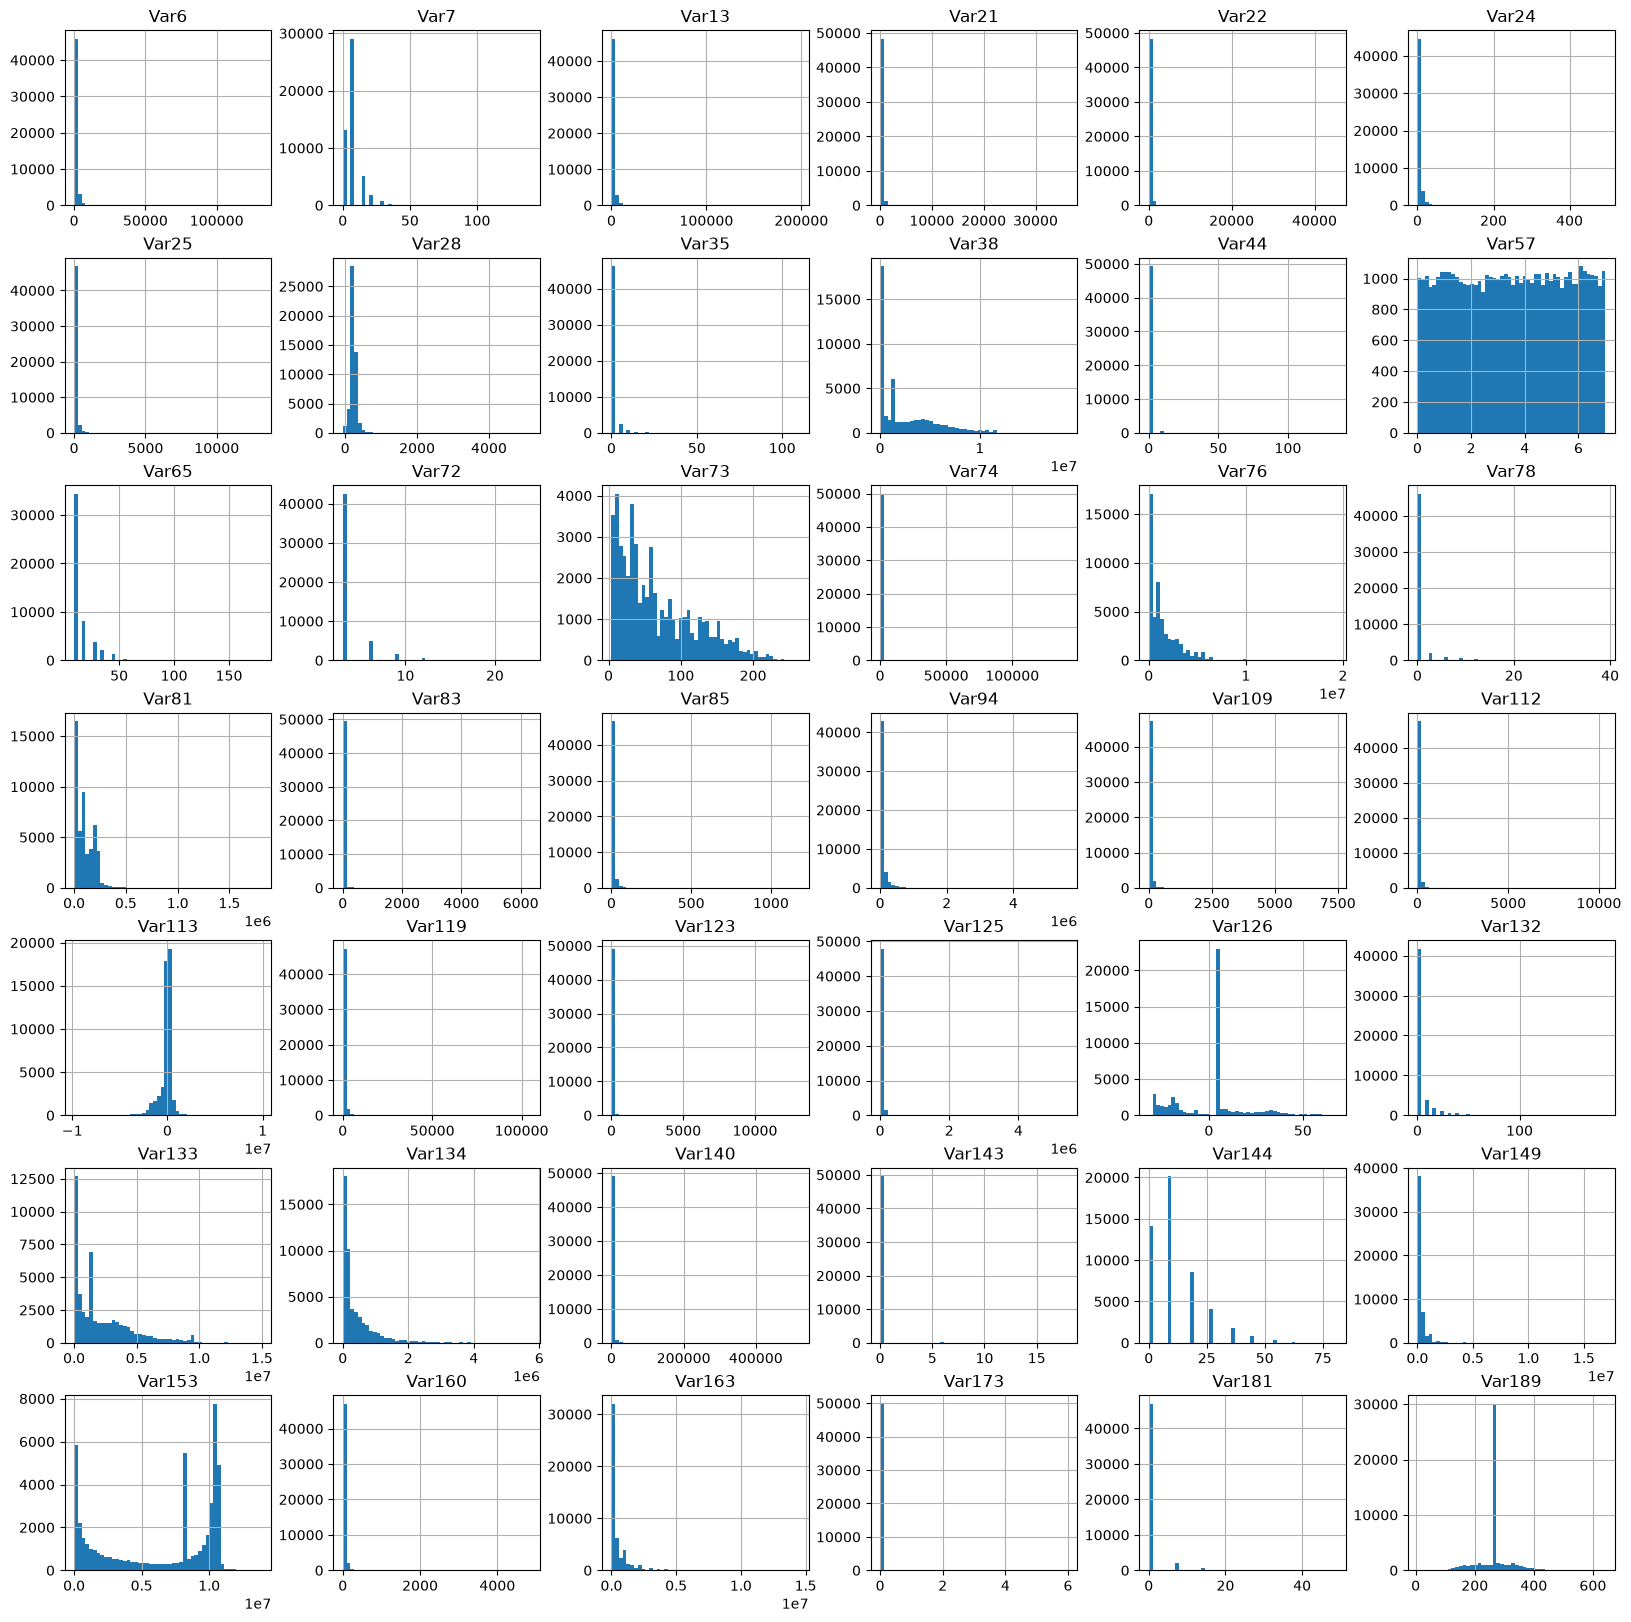

In [7]:
num_vars = data.select_dtypes(exclude="O").columns
data[num_vars].hist(bins=50, figsize=(20,20))
plt.plot()

In [8]:
cat_vars = data.select_dtypes(include="O").columns

data[cat_vars].nunique()

Var192    1
Var193    3
Var194    4
Var195    2
Var196    4
Var197    6
Var198    2
Var199    1
Var200    2
Var201    3
Var202    1
Var203    3
Var204    1
Var205    4
Var206    7
Var207    4
Var208    3
Var210    2
Var211    2
Var212    4
Var214    2
Var216    5
Var217    1
Var218    3
Var219    3
Var220    2
Var221    4
Var222    2
Var223    5
Var225    4
Var226    8
Var227    4
Var228    4
Var229    5
dtype: int64

In [9]:
data = OneHotEncoder(drop_last=True).fit_transform(data)

data.shape

(50000, 119)

In [10]:
target.replace({-1: 0}, inplace=True)

target.unique()

array([0, 1])

In [11]:
data["target"] = target

data["target"].mean()

np.float64(0.0178)

In [12]:
data.to_csv("../kdd_orange.csv", index=False)